- <span style="color:skyblue">ПЕРЕЙДЁМ КО 2-Й ЧАСТИ: ПОЛНОСТЬЮ ПРОАНАЛИЗИРУЕМ И ПРОТЕСТИРУЕМ ДАТАСЕТ "data_2.csv" С ЦЕЛЬЮ ПРОГНОЗИРОВАНИЯ ОТЧИСЛЕНИЯ СТУДЕНТОВ, А ТАКЖЕ ИХ УСПЕХОВ В УЧЁБЕ</span>

In [323]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats
from scipy.stats import mannwhitneyu
from scipy.stats import kruskal
from scipy.stats import shapiro
from scipy.stats import mannwhitneyu
from scipy.stats import chi2_contingency

In [324]:
# Инициализируем датасет с данными о студентах
df2 = pd.read_csv('data_2.csv', sep=';')
df2 = df2[['Marital status', 'Course', 'Admission grade', 'Debtor', 'Gender', 'Age at enrollment', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Target', 'Tuition fees up to date', 'Mother\'s qualification', 'Father\'s qualification']]

df2.columns

Index(['Marital status', 'Course', 'Admission grade', 'Debtor', 'Gender',
       'Age at enrollment', 'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)', 'Target', 'Tuition fees up to date',
       'Mother's qualification', 'Father's qualification'],
      dtype='object')

<span style="color:yellow">Личные данные студента:</span>
1. Marital status - семейное положение студента (категориальный: single, married, divorced и т.п.).
2. Application mode - способ подачи заявления (тип приема: online, transfer, exam, special regime и т.п.).
3. Application order - порядок выбора курса в заявлении (1-й выбор, 2-й выбор и т.д.).
4. Course - направление обучения (инженерия, менеджмент, информатика и т.п.).
5. Daytime/evening attendance - форма посещения: дневная или вечерняя программа.
6. Previous qualification - тип предыдущего образования (high school, vocational, bachelor и т.д.).
7. Previous qualification (grade) - оценка, полученная при предыдущей квалификации (балл, % или ранжированная шкала).
8. Nationality - гражданство / страна происхождения.
9. Mother’s qualification - уровень образования матери (high school, university, none и т.п.).
10. Father's qualification - уровень образования отца.
11. Mother’s occupation - профессия матери (кодируется числами).
12. Father’s occupation - профессия отца (кодируется числами).
13. Admission grade - баллы за вступление / средний балл при поступлении.
14. Displaced - перемещённый студент (да/нет) — например, из-за семейных/социальных обстоятельств.
15. Educational special needs - наличие особых образовательных потребностей (ОВЗ) — да/нет.
16. Debtor - есть ли задолженность по учебным предметам.
17. Tuition fees up to date - оплачены ли учебные взносы.
18. Gender - пол студента.
19. Scholarship holder - получает ли студент стипендию (да/нет).
20. Age at enrollment - возраст на момент поступления.
21. International - иностранный студент (да/нет).

<span style="color:yellow">Академические показатели по семестрам:</span>

22. Curricular units 1st sem (credited) - количество зачтённых предметов (1-й семестр).

23. Curricular units 1st sem (enrolled) - количество предметов, на которые студент записан (1-й семестр).

24. Curricular units 1st sem (evaluations) - количество проведённых оценочных мероприятий (экзамены, зачёты) в 1-м семестре.

25. Curricular units 1st sem (approved) - количество успешно сданных предметов в 1-м семестре.

26. Curricular units 1st sem (grade) - средняя оценка за 1-й семестр.

27. Curricular units 1st sem (without evaluations) - количество предметов без оценивания (пропущено / не допущен).

28. Curricular units 2nd sem (credited) - аналогично пункту 22, но для 2-го семестра.

29. Curricular units 2nd sem (enrolled) - аналогично пункту 23 для 2-го семестра.

30. Curricular units 2nd sem (evaluations) - аналогично пункту 24 для 2-го семестра.

31. Curricular units 2nd sem (approved) - аналогично пункту 25 для 2-го семестра.

32. Curricular units 2nd sem (grade) - аналогично пункту 26 для 2-го семестра.

33. Curricular units 2nd sem (without evaluations) - аналогично пункту 27 для 2-го семестра.

34. Unemployment rate - уровень безработицы в стране в год поступления.

35. Inflation rate - уровень инфляции.

36. GDP - валовый внутренний продукт (на душу населения или индекс).

<span style="color:yellow">Целевая переменная:</span>

37. Target

<span style="color:yellow">Статус студента:</span>

- 0 — Dropout (отчислен)

- 1 — Graduate (выпускник)

- 2 — Enrolled (на обучении)

In [325]:
df2['Target'].unique()

array(['Dropout', 'Graduate', 'Enrolled'], dtype=object)

In [326]:
df2['Target'] = df2['Target'].map({'Dropout': 0, 'Graduate': 1, 'Enrolled': 2})

В ходе всего анализа проверим три следующие <u>гипотезы</u>:

1) <span style="color:skyblue">Возраст при поступлении у отчисленных студентов выше, чем у выпускников</span>

2) <span style="color:skyblue">Средний балл при поступлении у выпускников выше, чем у отчисленных`</span>

3) <span style="color:skyblue">Уровень образования родителей студента статистически связан с вероятностью его выпуска из учебного заведения</span>

---

`1) Возраст при поступлении у отчисленных студентов выше, чем у выпускников`

Через статистические критерии будем проверять следующие гипотезы (в каждом из тестов считаем $α = 0.05$):

- Возраст при поступлении у отчисленных **не выше**, чем у выпускников.

- Возраст при поступлении у отчисленных **выше**, чем у выпускников.

In [327]:
# Выбираем две группы: студенты, которые бросили учёбу (Target = 0) и те, кто окончил учёбу (Target = 1)

dropout_and_graduated = df2[df2['Target'].isin([0, 1])][['Age at enrollment', 'Target']]
age_dropout = dropout_and_graduated.loc[dropout_and_graduated['Target'] == 0, 'Age at enrollment']
age_graduated = dropout_and_graduated.loc[dropout_and_graduated['Target'] == 1, 'Age at enrollment']

In [328]:
print('Выборочное среднее age_graduated: ', np.mean(age_graduated), '\nМедиана age_graduated: ', np.median(age_graduated))
print('Выборочное среднее age_dropout: ', np.mean(age_dropout), '\nМедиана age_dropout: ', np.median(age_dropout))

Выборочное среднее age_graduated:  21.78361249434133 
Медиана age_graduated:  19.0
Выборочное среднее age_dropout:  26.06896551724138 
Медиана age_dropout:  23.0


- `Среднее и медиана возраста при поступлении у закончивших ВУЗ меньше, чем у отчисленных, что косвенно подтверждает нашу гипотезу`

- `Визуализируем данные для дальнейшего анализа`

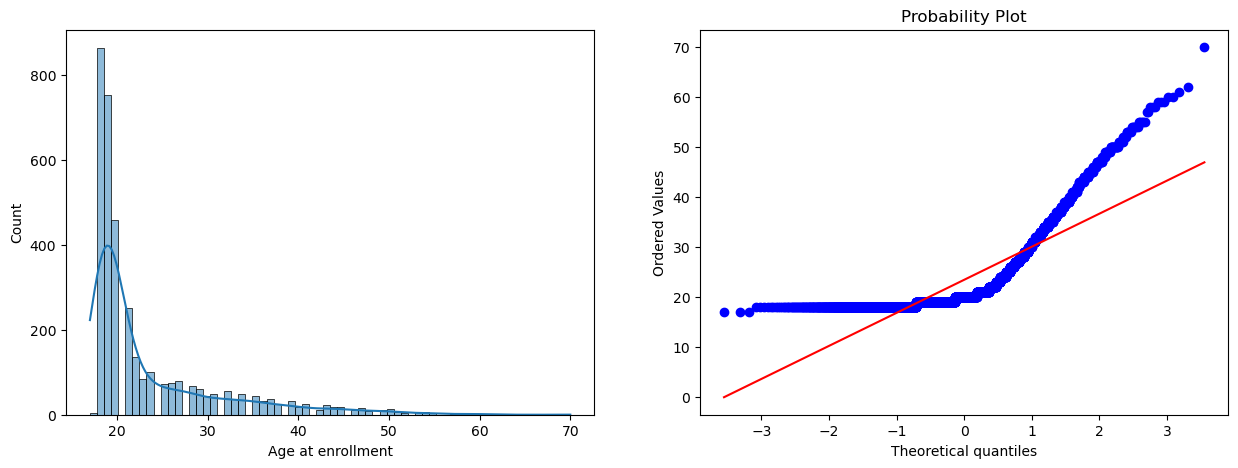

In [329]:
plt.figure(figsize=(15, 5))

plt.subplot(1,2,1)
sns.histplot(dropout_and_graduated['Age at enrollment'], kde=True)

plt.subplot(1,2,2)
stats.probplot(dropout_and_graduated['Age at enrollment'], dist='norm', plot=plt)

plt.show()

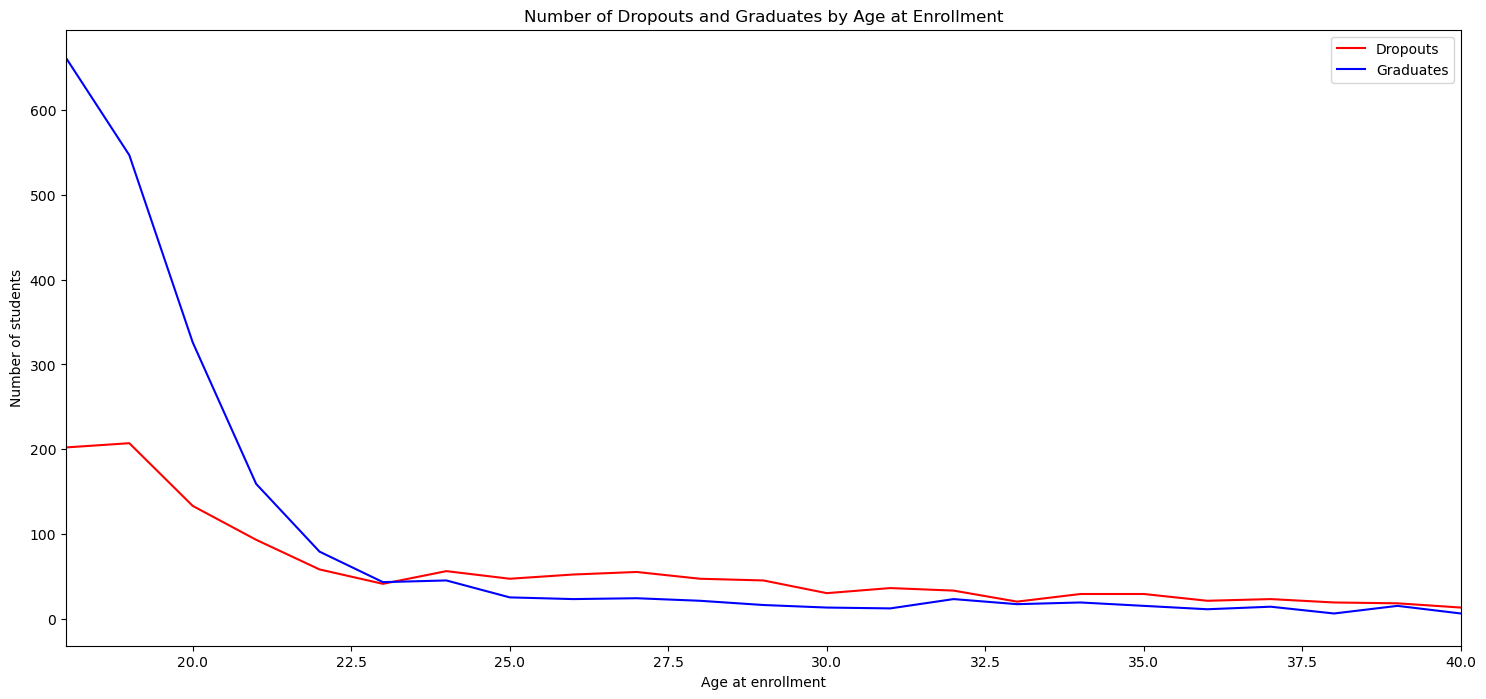

In [330]:
аge_groups = dropout_and_graduated.groupby(['Age at enrollment', 'Target']).size().unstack().dropna()

plt.figure(figsize=(18, 8))

plt.plot(аge_groups.index, аge_groups[0], color='red', label='Dropouts')
plt.plot(аge_groups.index, аge_groups[1], color = 'blue', label='Graduates')

plt.xlabel('Age at enrollment')
plt.ylabel('Number of students')
plt.title('Number of Dropouts and Graduates by Age at Enrollment')
plt.xlim(18, 40)
plt.legend()

plt.show()

Построим гипотезы для теста Шапиро-Уилка (тест на нормальность распределения):

- $H_0$: Данные распределены **нормально**

- $H_1$: Данные распределены **не нормально**

In [331]:
stat_dropout_and_graduated, p_dropout_and_graduated = shapiro(dropout_and_graduated)
print('p-value: ', p_dropout_and_graduated)

p-value:  8.259881161504454e-68


/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7260.
  res = hypotest_fun_out(*samples, **kwds)


- $p-value < 0.05,$ следовательно, распределения не подчиняются нормальному закону

**Проведём односторонний тест Манна-Уитни, так как мы хотим проверить, что возраст у отчисленных при поступление строго больше, чем у окончивших заведение**

In [332]:
stat, p_value = mannwhitneyu(age_dropout, age_graduated, alternative='greater')
print('p_value:', p_value)

p_value: 1.2258050862964577e-80


<span style="color:skyblue">ИТОГ ДЛЯ 1 ГИПОТЕЗЫ:</span>

Статистический вывод показал, что возраст при поступлении у отчисленных студентов статистически значимо выше, чем у окончивших.

---

`2) Средний балл при поступлении у выпускников выше, чем у отчисленных`

- $H_0$: Средний бал при поступлении у выпускников **не выше**, чем у отчисленных

- $H_1$: Средний бал при поступлении у выпускников **выше**, чем у отчисленныхл

In [333]:
df_gip2 = df2.copy()

# Разделяем баллы при поступлении на группы с шагом 20, чтобы улучшить читаемость графика
bins = np.arange(0,201,20)
df_gip2['Admission_group'] = pd.cut(df_gip2['Admission grade'], bins=bins, right=True, include_lowest=True)


In [334]:
# Разделяем данные на две группы: отчисленные и неотчисленные
df_drop = df_gip2[df_gip2['Target'] == 0]
df_good = df_gip2[df_gip2['Target'] == 1]

# Подсчитываем количество студентов в каждой группе по категориям баллов при поступлении
group_counts_drop = df_drop['Admission_group'].value_counts().sort_index()
group_counts_good = df_good['Admission_group'].value_counts().sort_index()

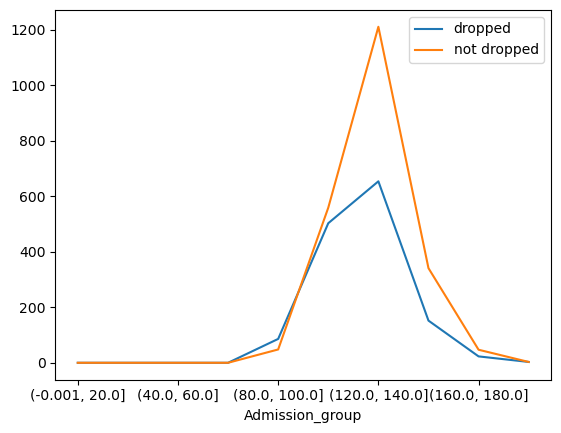

In [344]:
group_counts_drop.plot(kind='line', label='dropped')
group_counts_good.plot(kind='line', label='not dropped')
plt.legend()
plt.show()

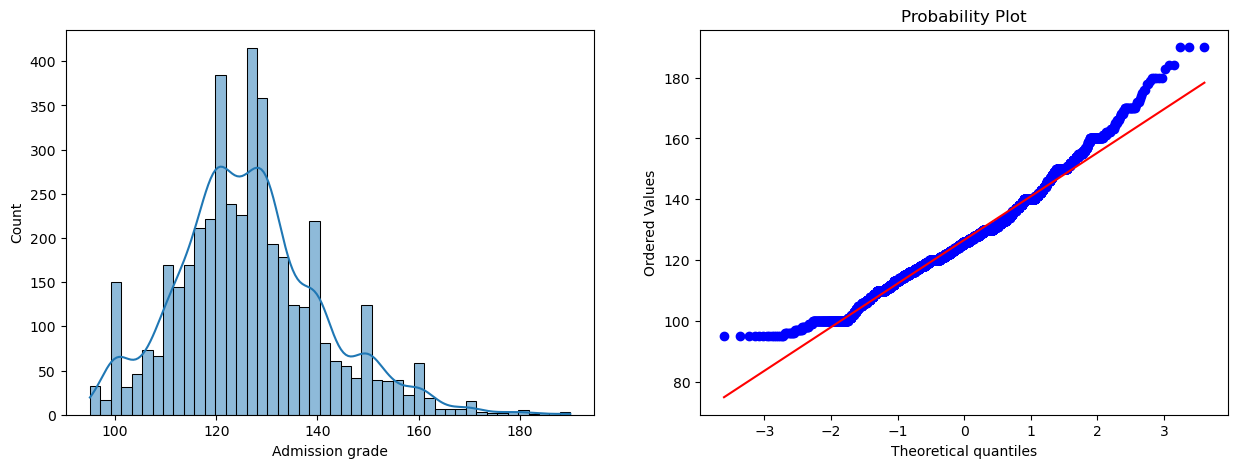

In [336]:
df_gip2['Admission grade'] = df_gip2['Admission grade'].astype(int)
df_gip2 = df_gip2.sort_values(by='Admission grade', ascending=False)

plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
sns.histplot(df_gip2['Admission grade'], kde=True)
plt.subplot(1,2,2)
stats.probplot(df_gip2['Admission grade'], dist='norm', plot=plt)
plt.show()

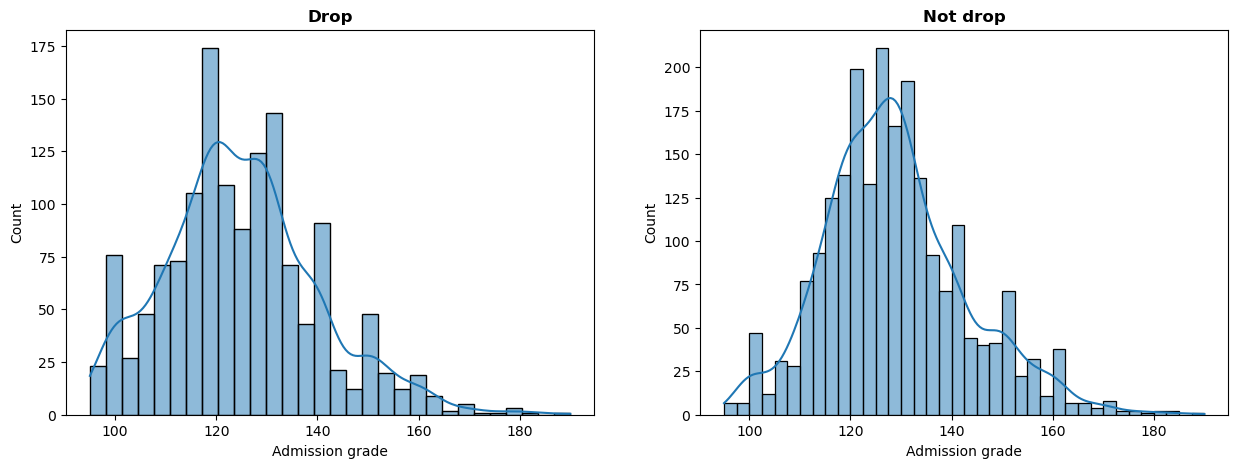

In [337]:
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
sns.histplot(df_drop['Admission grade'], kde=True)
plt.title('Drop', fontweight='bold')

plt.subplot(1,2,2)
sns.histplot(df_good['Admission grade'], kde=True)
plt.title('Not drop', fontweight='bold')

plt.show()


- Как видно из графиков распределение имеет скошенность и тяжёлые хвосты

**(1):** <u>Тест Шапиро-Уилка</u> для проверки распределения на нормальность:

- $H_0$: Данные распределены **нормально**

- $H_1$: Данные распределены **не нормально**

In [338]:
print('Для всех значений: ', stats.shapiro(df_gip2['Admission grade']).pvalue)
print('Для всех отчисленных: ', stats.shapiro(df_drop['Admission grade']).pvalue)
print('Для всех закончивших: ', stats.shapiro(df_good['Admission grade']).pvalue)

Для всех значений:  7.759629584379632e-25
Для всех отчисленных:  8.271526996698913e-14
Для всех закончивших:  1.192626636028019e-17



- $p-value = 7.76*10^{-25},$ то есть меньше 0.05 -> распределение выборки не является нормальным. 

**(2):** Для анализа самих подвыборок попробуем применить <u>**тест Краскала–Уоллиса**</u> - тест, основанный на рангах и находящий различия в распределении двух выборок. 

<u>**Как он работает?**</u> В каждой группе каждому значению присваивается свой ранг и после этого считается их сумма и выборочное среднее.


Продублируем гипотезы для этого теста:

- $H_0$: Средний бал при поступлении у выпускников **не выше**, чем у отчисленных

- $H_1$: Средний бал при поступлении у выпускников **выше**, чем у отчисленныхл

In [339]:
stat, p = kruskal(df_drop['Admission grade'], df_good['Admission grade'])
print('p-value: ', p)

p-value:  3.251793681232129e-15


- $p-value ≈ 3.25*10^{-15},$ что меньше 0.05, следовательно, гипотезу $H_0$ можно отвергнуть.

<span style="color:skyblue">ИТОГ ДЛЯ 2 ГИПОТЕЗЫ:</span>

- Средний балл при поступлении у выпускников выше, чем у отчисленных

---

`3) Уровень образования родителей студента статистически связан с вероятностью его выпуска из учебного заведения`

Так как студенты независимы и их достаточно большое количество, то для проверки гипотезы воспользуемся **<u>Хи-квадрат тестом</u>**. 

<u>Нулевая гипотеза</u>: наличие у родителей высшего образования не влияет на выпуск и отчисление студента.

<u>Альтернативная гипотеза</u>: связь между образованием родителей и выпуском/отчисления студента существует.

- Создадим дополнительную колонку, которая проверяет, есть ли хотя бы у одного из родителей высшее образование:

In [340]:
higher_education = {2, 3, 4, 5, 40, 41, 42, 43, 44}
df2['parents_have_higher_education'] = (df2["Mother's qualification"].isin(higher_education) | df2["Father's qualification"].isin(higher_education)).astype(int)
df2['parents_have_higher_education']

0       0
1       1
2       0
3       0
4       0
       ..
4419    0
4420    0
4421    0
4422    0
4423    0
Name: parents_have_higher_education, Length: 4424, dtype: int64

In [341]:
chi_t = df2[(df2['Target'] == 0) | (df2['Target'] == 1)][['parents_have_higher_education', 'Target']]

np.random.seed(100)
chi_data = pd.crosstab(chi_t['parents_have_higher_education'], chi_t['Target'])
chi_data

Target,0,1
parents_have_higher_education,,
0,1176,1852
1,245,357


In [342]:
chi2, p_value, dof, expected = chi2_contingency(chi_data)

print("p-value =", p_value)

p-value = 0.41889650921683264


Для Хи-квадрат теста получили $$p-value ≈ 0.419,$$ значит, нет оснований отвергать нулевую гипезу, поэтому наличие у родителей высшего образования не влияет на выпуск и отчисление студента.

- Визуализируем полученные данные:

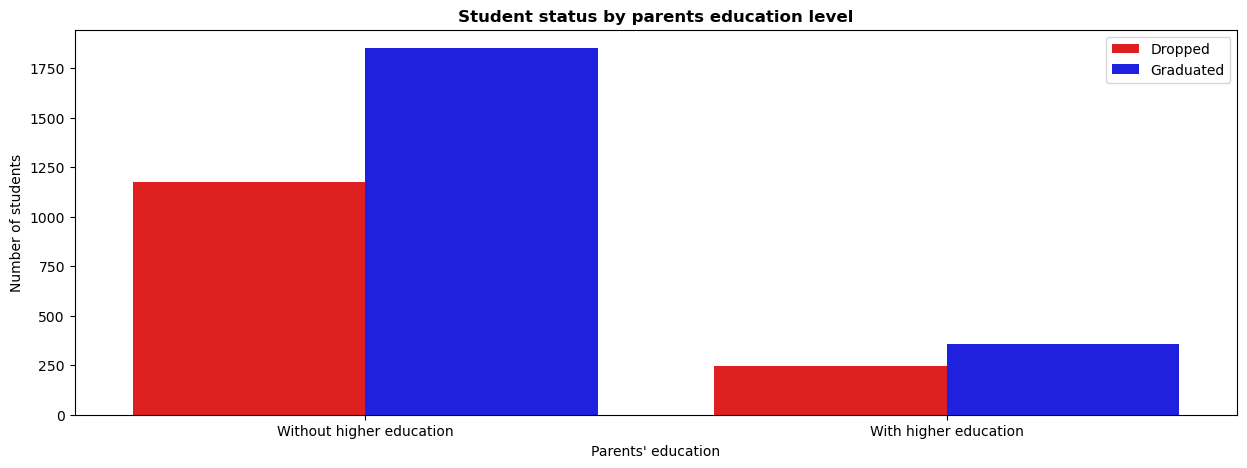

In [343]:
plt.figure(figsize=(15, 5))

sns.countplot(data = chi_t, x='parents_have_higher_education', hue = 'Target', palette=['red', 'blue'])

plt.xticks([0, 1], ['Without higher education', 'With higher education'])
plt.xlabel("Parents' education")
plt.ylabel('Number of students')
plt.legend(labels=['Dropped', 'Graduated'])
plt.title('Student status by parents education level', fontweight='bold')

plt.show()

<span style="color:skyblue">ИТОГ ДЛЯ 3 ГИПОТЕЗЫ:</span>

- Уровень образования родителей стастически значимо не влияет на успех или неудачу детей

<span style="color:yellow">ОБЩИЙ ВЫВОД:</span>

- Ключевыми факторами, связанными с успешным завершением обучения, являются индивидуальные характеристики студентов (возраст, средний балл), тогда как уровень образования родителей не влияет на успеваемость студентов.